In [743]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from io import StringIO
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image  
from sklearn.model_selection import GridSearchCV

In [744]:
data = pd.read_csv('../data/TelcoCustomerChurn.csv')

In [745]:
data.head

<bound method NDFrame.head of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL   

In [746]:
data.shape

(7043, 21)

In [747]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [748]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [749]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

In [750]:
data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [751]:
data = data.dropna(subset=["TotalCharges"])

In [752]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [753]:
data.duplicated().sum()

np.int64(0)

In [754]:
data = data.drop("customerID", axis=1)

In [755]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [756]:
data["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [757]:
data["Churn"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [758]:
data["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [759]:
data["Churn"].value_counts(normalize=True) * 100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

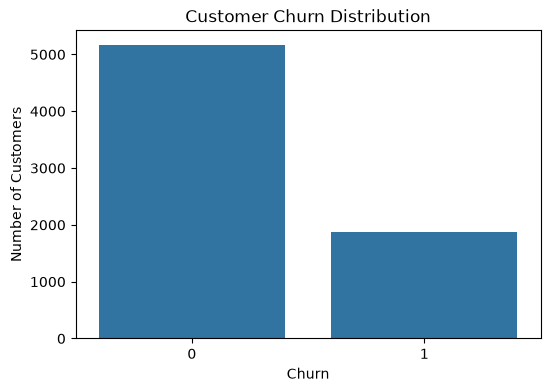

In [760]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=data,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

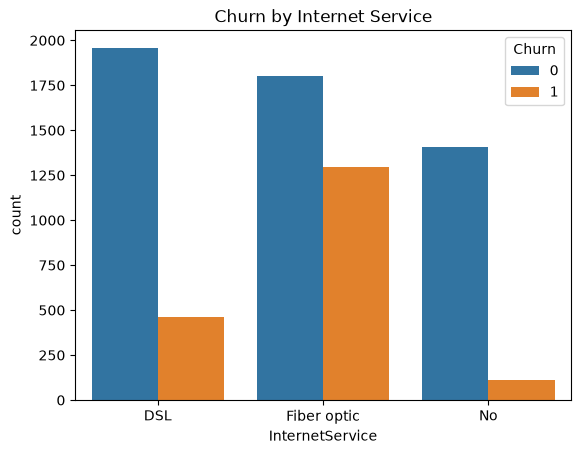

In [761]:
sns.countplot(
    data=data,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn by Internet Service")
plt.show()

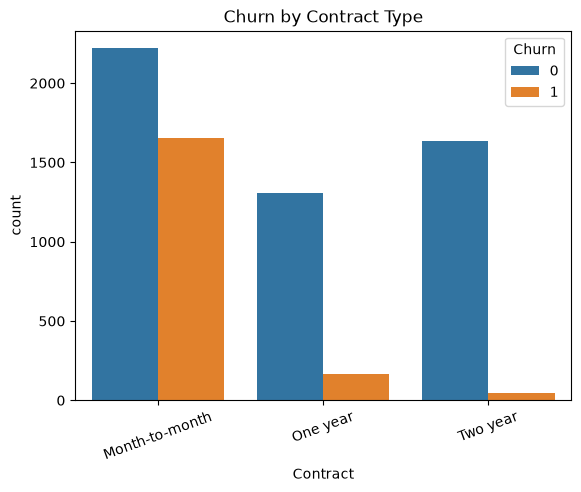

In [762]:
sns.countplot(
    data=data,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

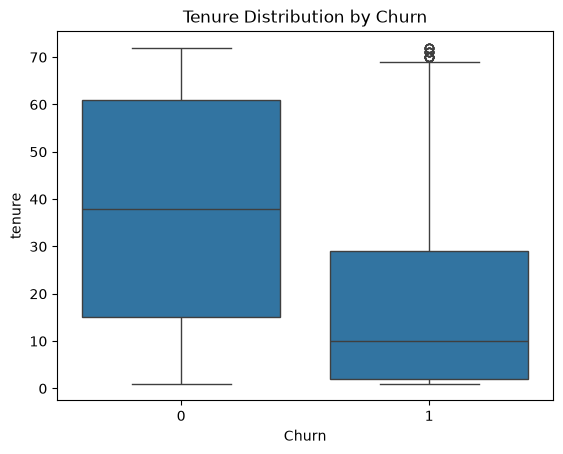

In [763]:
sns.boxplot(
    data=data,
    x="Churn",
    y="tenure"
)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("tenure")
plt.show()

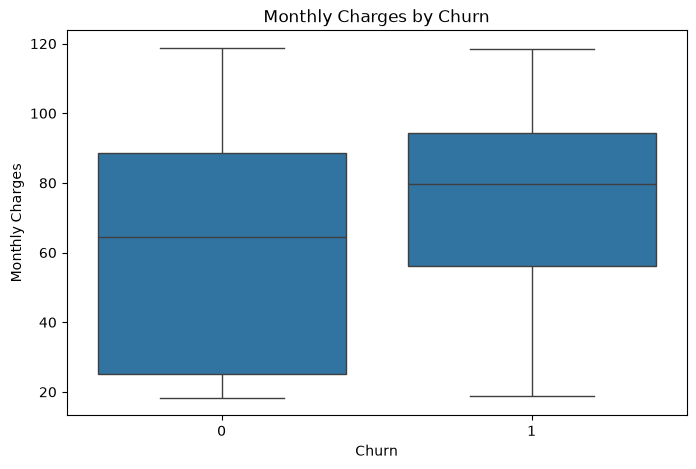

In [764]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

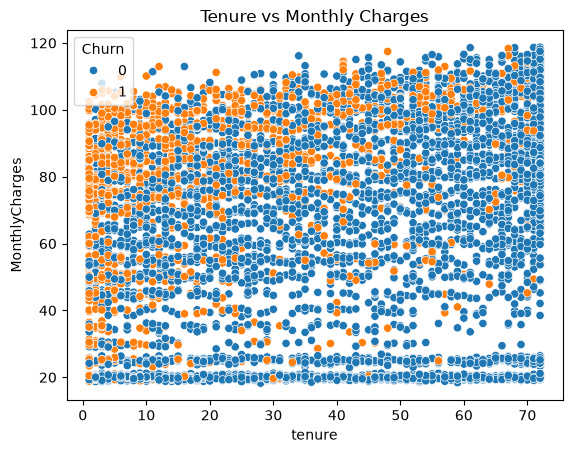

In [765]:
sns.scatterplot(
    data=data,x="tenure",
    y="MonthlyCharges", hue="Churn"
)
plt.title("Tenure vs Monthly Charges")
plt.show() #Tenure appears to have a stronger relationship with churn than monthly charges do. Customers with shorter tenure seem more likely to churn, while long-term customers are predominantly non-churners. However, churn can happen at almost any monthly charge level.

In [766]:
#Feature Engineering
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

data["ServiceCount"] = (
    data[service_cols] == "Yes"
).sum(axis=1)

In [767]:
pd.crosstab(data["ServiceCount"],data["Churn"],normalize="index") * 100

Churn,0,1
ServiceCount,,
0,78.535924,21.464076
1,54.244306,45.755694
2,64.181994,35.818006
3,72.605192,27.394808
4,77.647059,22.352941
5,87.521968,12.478032
6,94.718310,5.281690


In [768]:
def tenure_group(tenure):
    if tenure <= 12:
        return "New"
    elif tenure <= 36:
        return "Medium"
    else:
        return "Long-term"

data["TenureGroup"] = data["tenure"].apply(tenure_group)

In [769]:
pd.crosstab(
    data["TenureGroup"],
    data["Churn"],
    normalize="index"
) * 100

Churn,0,1
TenureGroup,,
Long-term,88.070643,11.929357
Medium,74.461207,25.538793
New,52.321839,47.678161


In [770]:
#Train/Test Split
X = data.drop('Churn', axis=1)
y = data['Churn']

In [771]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42, stratify=y)
print("TRAIN X SHAPE:",X_train.shape)
print("TRAIN Y SHAPE:",y_train.shape)
print("VALUE COUNTS:\n",y_train.value_counts())
print("TEST X SHAPE :",X_test.shape)
print("TEST Y SHAPE :",y_test.shape)

TRAIN X SHAPE: (4922, 21)
TRAIN Y SHAPE: (4922,)
VALUE COUNTS:
 Churn
0    3614
1    1308
Name: count, dtype: int64
TEST X SHAPE : (2110, 21)
TEST Y SHAPE : (2110,)


In [772]:
data["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [773]:
categorical_cols = X.select_dtypes(include='str').columns

In [774]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [775]:
print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount']


In [776]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",   "passthrough", numerical_cols),
        ("cat",   OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [777]:
model_1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42))
    ]
)

In [778]:
model_1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges','ServiceCount', 'TenureGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

In [779]:
def get_dt_graph(model):
    dot_data = StringIO()

    dt_classifier = model.named_steps["classifier"]
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()

    export_graphviz(
        dt_classifier,
        out_file=dot_data,
        filled=True,
        rounded=True,
        feature_names=feature_names,
        class_names=["No", "Yes"],
        proportion=True,
        precision=2
    )

    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

    return graph

In [780]:
gph = get_dt_graph(model_1)

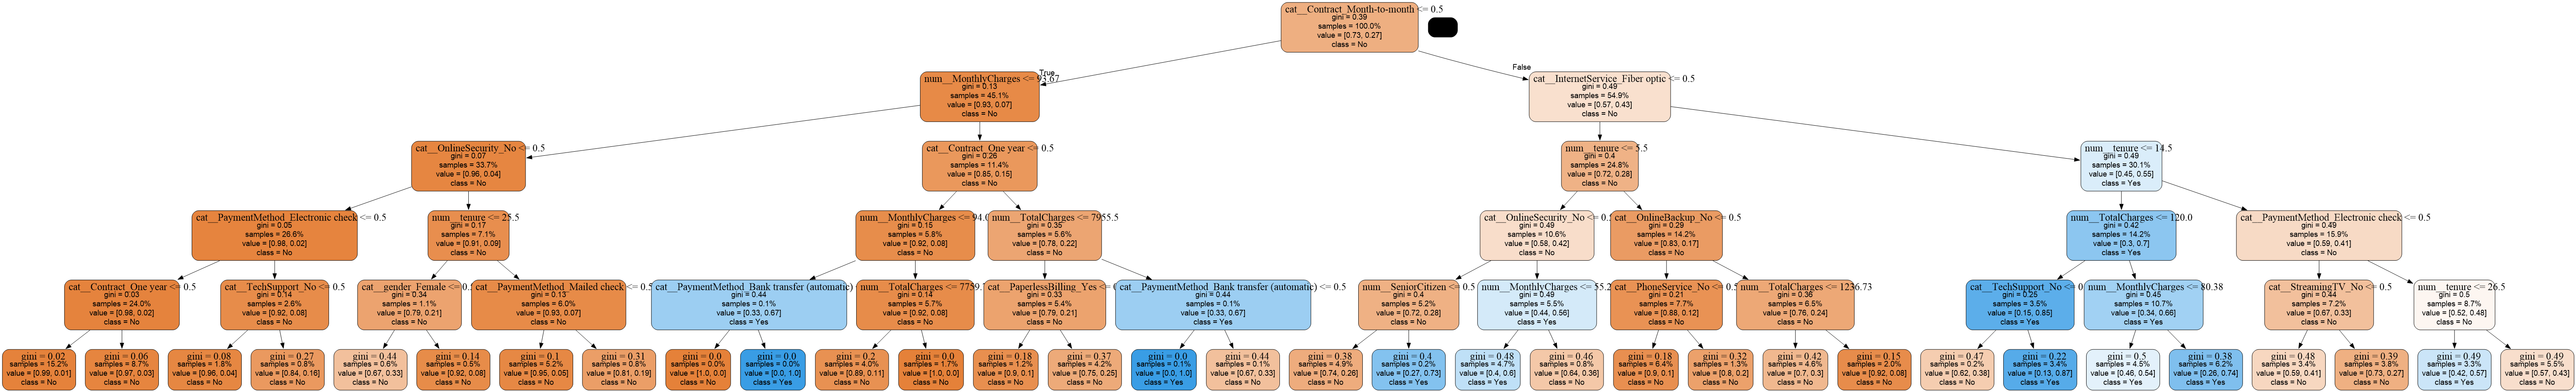

In [781]:
Image(gph.create_png())

In [782]:
y_pred_1 = model_1.predict(X_test)

In [783]:
accuracy_1 = accuracy_score(y_test, y_pred_1)
precision_1 = precision_score( y_test, y_pred_1,pos_label=1)
recall_1 = recall_score(y_test,y_pred_1,pos_label=1)
f1_score_1 = f1_score(y_test,y_pred_1, pos_label=1)
confusion_metrix_1 = confusion_matrix(y_test,y_pred_1,labels=[0, 1])

In [784]:
print("Model 1")
print("Accuracy :", accuracy_1)
print("Precision:", precision_1)
print("Recall   :", recall_1)
print("F1 Score :", f1_score_1)
print("Confusion Matrix:")
print(confusion_metrix_1)

Model 1
Accuracy : 0.7881516587677725
Precision: 0.6239130434782608
Recall   : 0.5115864527629234
F1 Score : 0.5621939275220372
Confusion Matrix:
[[1376  173]
 [ 274  287]]


In [786]:
params = {
    'classifier__max_depth': [3, 4, 5, 6, 8, 10],
    'classifier__criterion': ["gini", "entropy"],
    'classifier__class_weight': [None, 'balanced']
}

In [787]:
model_2 = Pipeline(
    steps=[("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [788]:
grid_search = GridSearchCV(estimator=model_2, 
                           param_grid=params, 
                           cv=4, n_jobs=-1, verbose=1, scoring={
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
},
refit="f1")

In [789]:
#model_2.fit(X_train, y_train)
grid_search.fit(X_train, y_train)

Fitting 4 folds for each of 24 candidates, totalling 96 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced'], 'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... vers

In [790]:
score_df = pd.DataFrame(grid_search.cv_results_)
score_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__class_weight,param_classifier__criterion,param_classifier__max_depth,params,split0_test_accuracy,split1_test_accuracy,...,mean_test_recall,std_test_recall,rank_test_recall,split0_test_f1,split1_test_f1,split2_test_f1,split3_test_f1,mean_test_f1,std_test_f1,rank_test_f1
0,0.608636,0.124074,0.060392,0.004416,NaN,gini,3,"{'classifier__class_weight': None, 'classifier...",0.780666,0.798538,...,0.334098,0.047739,23,0.476744,0.500000,0.385650,0.433333,0.448932,0.043673,23
1,0.583073,0.142240,0.069787,0.020327,NaN,gini,4,"{'classifier__class_weight': None, 'classifier...",0.779854,0.805849,...,0.509174,0.041114,19,0.518650,0.578483,0.560386,0.568750,0.556567,0.022809,15
2,0.602365,0.330119,0.066676,0.005354,NaN,gini,5,"{'classifier__class_weight': None, 'classifier...",0.773355,0.808286,...,0.501529,0.100383,21,0.572741,0.632399,0.466019,0.514991,0.546538,0.062324,18
3,0.288359,0.077708,0.082647,0.033071,NaN,gini,6,"{'classifier__class_weight': None, 'classifier...",0.772543,0.796101,...,0.503823,0.070448,20,0.562500,0.594507,0.489320,0.545161,0.547872,0.038159,17
4,0.168426,0.025821,0.108939,0.085003,NaN,gini,8,"{'classifier__class_weight': None, 'classifier...",0.757920,0.783103,...,0.521407,0.044553,15,0.541538,0.588598,0.516129,0.533552,0.544954,0.026820,19


In [791]:
score_df.nlargest(5, "mean_test_f1")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__class_weight,param_classifier__criterion,param_classifier__max_depth,params,split0_test_accuracy,split1_test_accuracy,...,mean_test_recall,std_test_recall,rank_test_recall,split0_test_f1,split1_test_f1,split2_test_f1,split3_test_f1,mean_test_f1,std_test_f1,rank_test_f1
13,0.172831,0.036795,0.081431,0.031884,balanced,gini,4,"{'classifier__class_weight': 'balanced', 'clas...",0.754671,0.740049,...,0.772171,0.043491,3,0.612821,0.627907,0.633822,0.624703,0.624813,0.007658,1
20,0.165457,0.081625,0.082403,0.048547,balanced,entropy,5,"{'classifier__class_weight': 'balanced', 'clas...",0.742486,0.765232,...,0.760703,0.031215,5,0.605230,0.636478,0.629333,0.617371,0.622103,0.011895,2
19,0.145350,0.067179,0.065600,0.039299,balanced,entropy,4,"{'classifier__class_weight': 'balanced', 'clas...",0.755483,0.740049,...,0.756881,0.062092,7,0.592693,0.627907,0.633822,0.624703,0.619781,0.015978,3
12,0.230100,0.065223,0.085479,0.024614,balanced,gini,3,"{'classifier__class_weight': 'balanced', 'clas...",0.721365,0.761170,...,0.794343,0.009997,1,0.601626,0.642336,0.637363,0.593714,0.618760,0.021347,4
18,0.114351,0.011536,0.048879,0.006505,balanced,entropy,3,"{'classifier__class_weight': 'balanced', 'clas...",0.721365,0.761170,...,0.794343,0.009997,1,0.601626,0.642336,0.637363,0.593714,0.618760,0.021347,4


In [792]:
grid_search.best_estimator_
dt_best = grid_search.best_estimator_

In [793]:
y_pred_2 = dt_best.predict(X_test)

In [794]:
gph_2 = get_dt_graph(dt_best)

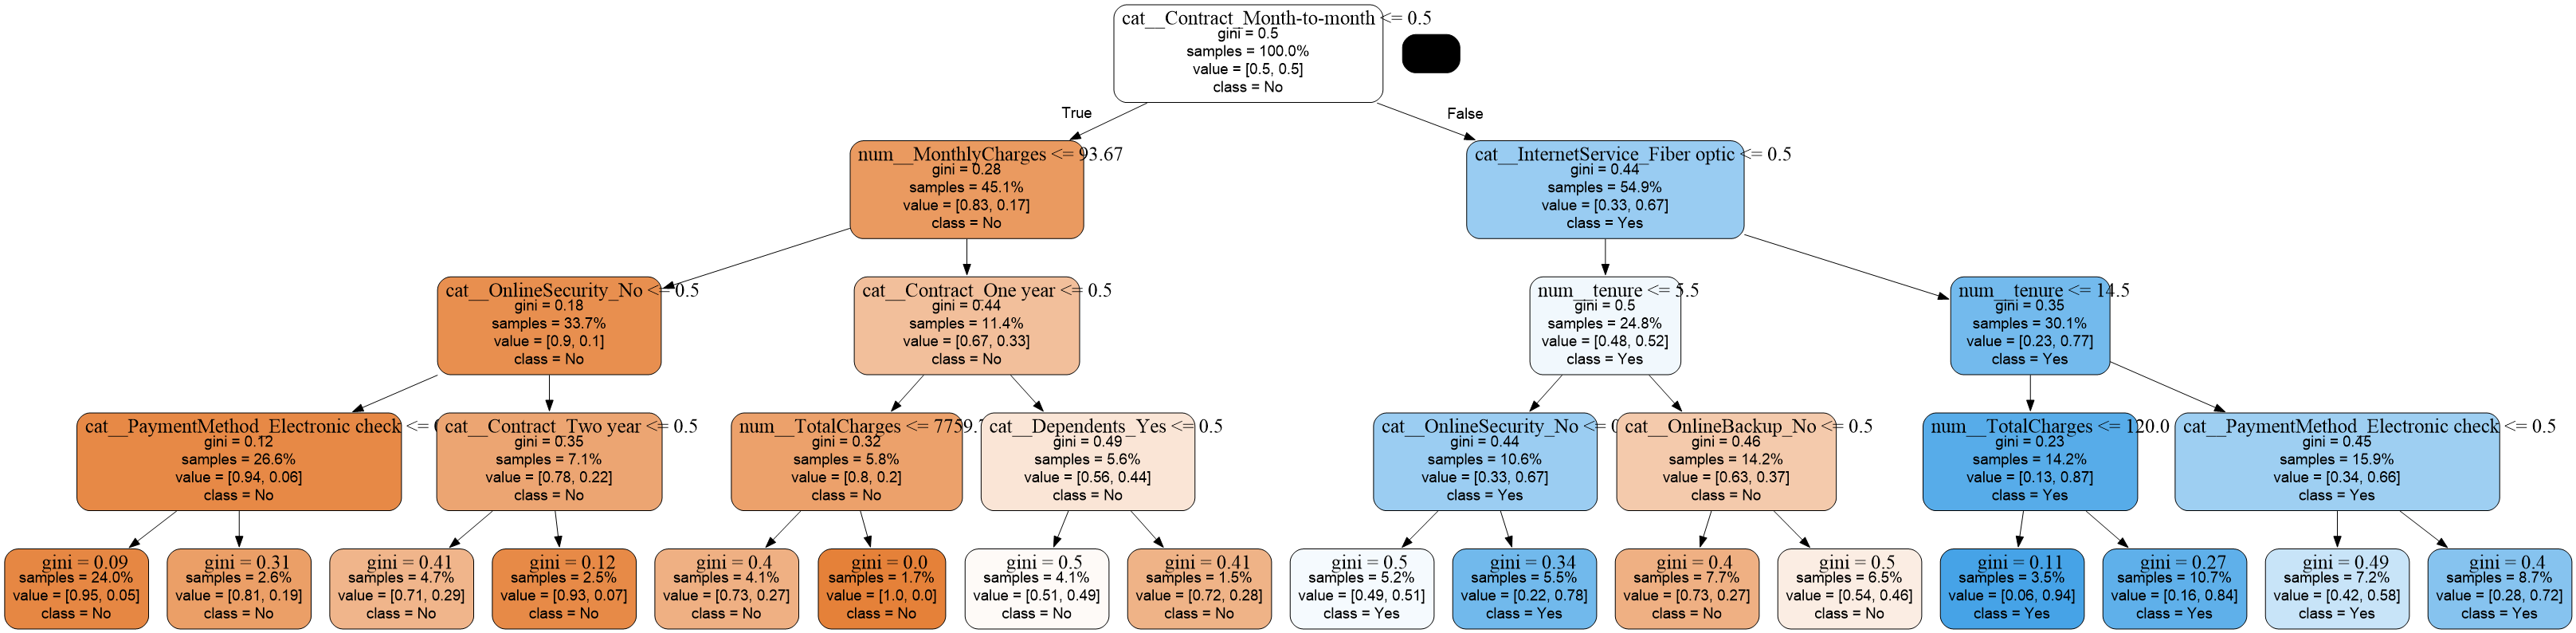

In [795]:
Image(gph_2.create_png())

In [796]:
accuracy_2 = accuracy_score(y_test, y_pred_2)
precision_2 = precision_score( y_test, y_pred_2,pos_label=1)
recall_2 = recall_score(y_test,y_pred_2,pos_label=1)
f1_score_2 = f1_score(y_test,y_pred_2, pos_label=1)
confusion_metrix_2 = confusion_matrix(y_test,y_pred_2,labels=[0, 1])

In [797]:
print("Model 2")
print("Accuracy :", accuracy_2)
print("Precision:", precision_2)
print("Recall   :", recall_2)
print("F1 Score :", f1_score_2)
print("Confusion Matrix:")
print(confusion_metrix_2)

Model 2
Accuracy : 0.7355450236966825
Precision: 0.5017341040462427
Recall   : 0.7736185383244206
F1 Score : 0.6086956521739131
Confusion Matrix:
[[1118  431]
 [ 127  434]]


In [798]:
comparison = pd.DataFrame({
    "Model": [
        "Model 1 - Gini, depth 5",
        "Model 2 - tunned, depth 5"
    ],
    "Accuracy": [
        accuracy_1,
        accuracy_2
    ],
    "Precision": [
        precision_1,
        precision_2
    ],
    "Recall": [
        recall_1,
        recall_2
    ],
    "F1 Score": [
        f1_score_1,
        f1_score_2
    ]
})

print(comparison)

                       Model  Accuracy  Precision    Recall  F1 Score
0    Model 1 - Gini, depth 5  0.788152   0.623913  0.511586  0.562194
1  Model 2 - tunned, depth 5  0.735545   0.501734  0.773619  0.608696


In [799]:
final_model = dt_best

In [800]:
classifier = final_model.named_steps["classifier"]
preprocessor_fitted = final_model.named_steps["preprocessor"]
feature_names = preprocessor_fitted.get_feature_names_out()
importances = classifier.feature_importances_

In [801]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [802]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

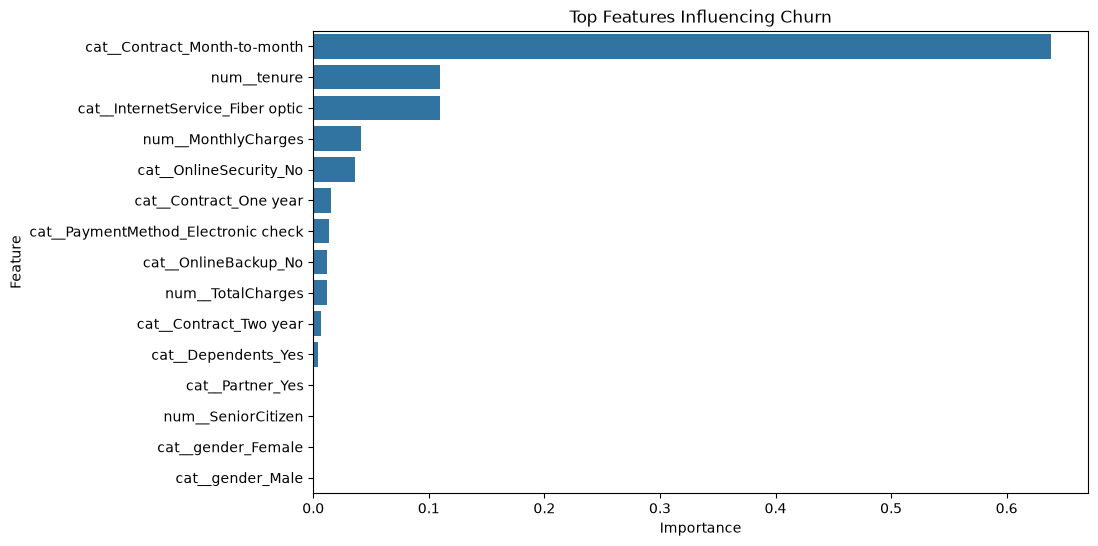

In [803]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Features Influencing Churn")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [804]:
import joblib

joblib.dump(
    final_model,
    "../model/churn_model.pkl"
)
print("Model saved successfully.")

Model saved successfully.


In [805]:
loaded_model = joblib.load("../model/churn_model.pkl")

In [806]:
test_prediction = loaded_model.predict(
    X_test.iloc[:10]
)
print(test_prediction)

[1 0 0 0 0 0 0 0 0 0]


In [807]:
probabilities = loaded_model.predict_proba(
    X_test.iloc[:10]
)
probability_of_churn = probabilities[:, 1]
print(probability_of_churn)

[0.51246627 0.46152398 0.         0.29301119 0.04771533 0.18972722
 0.46152398 0.27246409 0.04771533 0.18972722]
